## UPSC Essay Evaluator - Parallel Workflow

## Concepts
- Parallel Workflow
- Structured Output
- Reducer Function

In [26]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [3]:
load_dotenv() # will see what it does behind the scenes

False

In [ ]:
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", api_key="GOOGLE_API_KEY")

In [8]:
response = model.invoke("Write me a ballad about LangChain")

In [11]:
response

AIMessage(content=[{'type': 'text', 'text': 'The code was cold, the prompt was dry,\nThe LLM had lost its way,\nIt wandered through a latent sky\nWhere logic turned to shades of gray.\nWe fed it context, line by line,\nBut memory was a fleeting ghost,\nUntil we built a bridge divine—\nA framework for the restless host.\n\n*Oh, LangChain, weave the tether tight,*\n*Between the mind and static page,*\n*You guide the spark through endless night,*\n*And step the actor on the stage.*\n\nWe fashioned Chains of thought and stone,\nTo link the prompt to tools of fire,\nThe model stood no more alone,\nBut built a bridge to its desire.\nWith Agents sharp as razors drawn,\nIt searched the web and scanned the chart,\nTo greet the logic of the dawn\nWith silicon inside its heart.\n\nIt parsed the docs in Vector space,\nWith Embeddings long and secrets deep,\nRetrieving truth at lightning pace\nWhile all the sleeping servers sleep.\nThe RAG was sung—a haunting hymn—\nOf data retrieved from dusty pil

In [15]:
print(response.content[0]["text"])

The code was cold, the prompt was dry,
The LLM had lost its way,
It wandered through a latent sky
Where logic turned to shades of gray.
We fed it context, line by line,
But memory was a fleeting ghost,
Until we built a bridge divine—
A framework for the restless host.

*Oh, LangChain, weave the tether tight,*
*Between the mind and static page,*
*You guide the spark through endless night,*
*And step the actor on the stage.*

We fashioned Chains of thought and stone,
To link the prompt to tools of fire,
The model stood no more alone,
But built a bridge to its desire.
With Agents sharp as razors drawn,
It searched the web and scanned the chart,
To greet the logic of the dawn
With silicon inside its heart.

It parsed the docs in Vector space,
With Embeddings long and secrets deep,
Retrieving truth at lightning pace
While all the sleeping servers sleep.
The RAG was sung—a haunting hymn—
Of data retrieved from dusty piles,
To fill the void, however dim,
With structured facts and measured mil

In [16]:
# for structured output
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay")
    score: int = Field(description="Score out of 10 based on the evaluation criteria", ge=0, le=10)

In [17]:
structured_model = model.with_structured_output(EvaluationSchema)

In [18]:
essay_text = """
# Role of AI in India

Artificial Intelligence (AI) is transforming the world at an extraordinary pace, and India is emerging as one of the leading nations in adopting and developing AI technologies. With its strong IT industry, large population, growing startup ecosystem, and digital infrastructure, India has immense potential to benefit from AI in various sectors such as healthcare, education, agriculture, business, governance, and transportation. AI is not only changing the way people work and live but is also contributing to the country’s economic growth and social development.

One of the most important roles of AI in India is in the healthcare sector. India faces challenges such as a shortage of doctors, unequal healthcare access, and rising medical costs. AI-powered systems help doctors diagnose diseases faster and more accurately. Technologies such as machine learning and medical imaging can detect illnesses like cancer, tuberculosis, and heart disease at an early stage. AI chatbots and virtual assistants also provide basic medical advice to patients in remote areas. During the COVID-19 pandemic, AI played a major role in tracking cases, analyzing data, and accelerating vaccine research.

AI is also revolutionizing education in India. Online learning platforms use AI to personalize education according to the needs of students. AI tools can analyze a student’s strengths and weaknesses and provide customized lessons and practice tests. Virtual tutors and language translation systems make education more accessible to students from different regions and backgrounds. This is especially useful in a diverse country like India, where students speak many different languages.

In agriculture, AI is helping farmers improve productivity and reduce losses. Indian farmers often face problems such as unpredictable weather, pest attacks, and lack of proper market information. AI-based applications can predict weather conditions, monitor soil quality, detect crop diseases, and suggest the best farming practices. Drones and smart irrigation systems powered by AI are also helping farmers use water and fertilizers more efficiently. These technologies increase crop yield and support sustainable farming.

The business and industrial sectors are also benefiting greatly from AI. Many Indian companies are using AI for customer service, data analysis, cybersecurity, and automation. AI-powered chatbots improve customer support, while predictive analytics help businesses make better decisions. In manufacturing, AI-driven robots and smart systems increase efficiency and reduce human error. India’s growing startup ecosystem is also creating innovative AI solutions for various industries.

Another important role of AI in India is in governance and public services. The government is using AI to improve digital services, traffic management, public safety, and fraud detection. Smart city projects use AI for surveillance, waste management, and efficient transportation systems. AI can also help government agencies analyze large amounts of data to make better policies and improve public administration.

Despite its advantages, AI also brings several challenges to India. One major concern is job displacement due to automation. Many routine and repetitive jobs may be replaced by machines in the future. There are also concerns related to privacy, data security, and ethical use of AI. To address these issues, India needs proper regulations, skilled professionals, and responsible AI development. Education and skill training programs are necessary to prepare people for an AI-driven future.

In conclusion, AI is playing a crucial role in shaping India’s future. It has the power to improve healthcare, education, agriculture, business, and governance while contributing to economic growth and innovation. However, the successful use of AI requires balanced development, ethical practices, and inclusive policies. If used wisely, AI can help India become a more advanced, efficient, and globally competitive nation in the coming years.

"""

In [19]:
prompt = f"Evaluate the language quality of an essay and provide feedback and a score out of 10. \nEssay: {essay_text}"

In [20]:
response = structured_model.invoke(prompt)

In [21]:
response

EvaluationSchema(feedback='The essay is exceptionally well-written, demonstrating a high level of clarity, coherence, and structural organization. Each paragraph focuses on a distinct sector, providing relevant examples and balanced perspectives. The grammar and vocabulary are professional and precise, making the text easy to follow. The introduction and conclusion effectively frame the discussion, and the acknowledgement of challenges (such as job displacement and ethical concerns) adds necessary depth and objectivity. No significant grammatical or structural errors were found.', score=10)

In [23]:
print(response.feedback)

The essay is exceptionally well-written, demonstrating a high level of clarity, coherence, and structural organization. Each paragraph focuses on a distinct sector, providing relevant examples and balanced perspectives. The grammar and vocabulary are professional and precise, making the text easy to follow. The introduction and conclusion effectively frame the discussion, and the acknowledgement of challenges (such as job displacement and ethical concerns) adds necessary depth and objectivity. No significant grammatical or structural errors were found.


In [24]:
response.score

10

In [27]:
# define state
class UPSCState(TypedDict):
    essay_text: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add] # reducer function - add
    average_score: float


In [28]:
def evaluate_language(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the language quality of an essay and provide feedback and a score out of 10. \nEssay: {state['essay_text']}"
    response = structured_model.invoke(prompt)
    return {"language_feedback": response.feedback, "individual_scores": [response.score]}

In [29]:
def evaluate_analysis(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the depth of analysis in an essay and provide feedback and a score out of 10. \nEssay: {state['essay_text']}"
    response = structured_model.invoke(prompt)
    return {"analysis_feedback": response.feedback, "individual_scores": [response.score]}

In [30]:
def evaluate_clarity(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the clarity of an essay and provide feedback and a score out of 10. \nEssay: {state['essay_text']}"
    response = structured_model.invoke(prompt)
    return {"clarity_feedback": response.feedback, "individual_scores": [response.score]}

In [31]:
def final_evaluation(state: UPSCState) -> UPSCState:
    # summary feedback
    prompt = f"Based on the feedback for language, analysis, and clarity, provide an overall evaluation of the essay. \nLanguage Feedback: {state['language_feedback']} \nAnalysis Feedback: {state['analysis_feedback']} \nClarity Feedback: {state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content[0]["text"]

    # average score calculation
    average_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {"overall_feedback": overall_feedback, "average_score": average_score}


In [34]:
# define graph
graph = StateGraph(UPSCState)

# define nodes
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("final_evaluation", final_evaluation)

# define edges
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_clarity")

graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_clarity", "final_evaluation")

graph.add_edge("final_evaluation", END)

# compile graph
workflow = graph.compile()

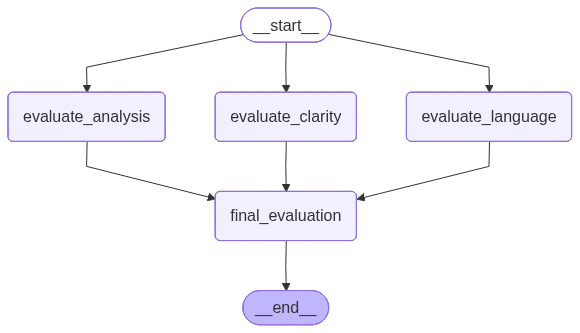

In [35]:
workflow

In [36]:
intial_state = {
    "essay_text": essay_text,
}

final_state = workflow.invoke(intial_state)

In [37]:
final_state

{'essay_text': '\n# Role of AI in India\n\nArtificial Intelligence (AI) is transforming the world at an extraordinary pace, and India is emerging as one of the leading nations in adopting and developing AI technologies. With its strong IT industry, large population, growing startup ecosystem, and digital infrastructure, India has immense potential to benefit from AI in various sectors such as healthcare, education, agriculture, business, governance, and transportation. AI is not only changing the way people work and live but is also contributing to the country’s economic growth and social development.\n\nOne of the most important roles of AI in India is in the healthcare sector. India faces challenges such as a shortage of doctors, unequal healthcare access, and rising medical costs. AI-powered systems help doctors diagnose diseases faster and more accurately. Technologies such as machine learning and medical imaging can detect illnesses like cancer, tuberculosis, and heart disease at 

In [38]:
print("Overall Feedback:", final_state['overall_feedback'])

Overall Feedback: Based on the comprehensive feedback provided across the three key pillars of academic writing, here is the overall evaluation of your essay:

### **Overall Evaluation**

**Grade: Excellent (High Distinction Potential)**

Your essay stands as a **highly accomplished piece of expository writing.** You have mastered the mechanics of formal structure, clarity, and professional tone, ensuring that your core message is accessible and logically presented. You have successfully navigated the breadth of the topic—AI’s impact on various Indian sectors—with a disciplined, organized approach that makes the complex subject matter easy to follow.

#### **Key Strengths:**
*   **Structural Integrity:** The organizational framework is your greatest asset. By categorizing the analysis by sector, you have provided a roadmap that allows the reader to digest information seamlessly.
*   **Linguistic Precision:** You possess a sophisticated command of language. The flow is consistent, the g

In [39]:
print("Score: ", final_state['average_score'])

Score:  8.0


In [40]:
essay_text = """
# Role of AI in India

AI is very important in India because now everything is becoming digital and modern. AI means Artificial Intelligence and it is used in many places and many peoples are using it every day. India is also growing in AI and many companies are making AI for future developments and technology purposes.

First of all, AI is helping in hospitals and doctors. Doctors can use AI machine for checking diseases and also patients are getting treatment very fastly. During corona time AI was useful because many datas were checked by computers and apps. AI can also talk with peoples by chatbot and solve health problems online.

Secondly, AI is also used in education sector. Students are studying from online apps and AI is helping them for learning things. Sometimes AI gives answers and notes also. Teachers can also use AI for checking homework and exams. It is very beneficial and useful for studies in India country.

Moreover, AI is helping farmers in agriculture field. Farmers can know weather conditions and crop problems from AI technologies. Drones are flying in farms and helping agriculture activities. Because India is agriculture country, AI is becoming very necessary for all farmers and village peoples.

In business also AI is used very highly. Big companies and small companies both are using AI for profits and customer support systems. AI can answer customers automatically and save time of employees. Factories are also using robots and machines for production and development works.

But AI also have disadvantages. Some peoples can lose jobs because machines can do works faster than humans. AI also can create hacking and privacy problems if not used properly. Government should make strict rules and regulations for AI systems and awareness.

In conclusion, AI is good thing for India and future generation. It has many advantages and some disadvantages also but overall it is very helpful and developing technology. India should use AI carefully and become more developed country in future times.

"""

In [41]:
intial_state = {
    "essay_text": essay_text,
}

final_state = workflow.invoke(intial_state)

In [42]:
final_state

{'essay_text': '\n# Role of AI in India\n\nAI is very important in India because now everything is becoming digital and modern. AI means Artificial Intelligence and it is used in many places and many peoples are using it every day. India is also growing in AI and many companies are making AI for future developments and technology purposes.\n\nFirst of all, AI is helping in hospitals and doctors. Doctors can use AI machine for checking diseases and also patients are getting treatment very fastly. During corona time AI was useful because many datas were checked by computers and apps. AI can also talk with peoples by chatbot and solve health problems online.\n\nSecondly, AI is also used in education sector. Students are studying from online apps and AI is helping them for learning things. Sometimes AI gives answers and notes also. Teachers can also use AI for checking homework and exams. It is very beneficial and useful for studies in India country.\n\nMoreover, AI is helping farmers in a

In [43]:
print("Overall Feedback:", final_state['overall_feedback'])
print("Score:", final_state['average_score'])

Overall Feedback: Based on the feedback provided, here is an overall evaluation of your essay:

### **Overall Evaluation: Developing**

Your essay demonstrates a solid foundational understanding of the topic, successfully organizing information into a coherent structure that covers AI’s role across various sectors in India. The reader can easily follow your train of thought, and your ability to categorize the benefits of AI into distinct sectors shows good organizational skills.

However, the essay currently functions more as an introductory overview than an academic analysis. To move to a higher level of performance, you must bridge the gap between **describing** AI and **critically analyzing** it.

#### **Key Strengths:**
*   **Logical Organization:** The essay is well-structured, using a clear, thematic approach that makes the content easy to digest.
*   **Effective Summarization:** The conclusion is strong, offering a balanced summary that ties the various points together well.
*  